# Máscaras espaciais dos clusters — verificação visual

Este notebook carrega o shapefile de clusters espaciais (`dataset/shp/shp_vento.shp`,
ver [documentation/03_clusters_espaciais.md](../documentation/03_clusters_espaciais.md)),
renomeia os identificadores brutos do shapefile para os `cluster_id` usados nas
pipelines (`cluster_lstm`, `cluster_mlp`, `cluster_lazy`, `cluster_gan`), plota
todas as máscaras (polígonos) lado a lado e isola a máscara do **cluster 3**
para conferência visual antes do uso downstream.

Exporta a máscara do cluster 3 isolada para `artifacts/cluster_masks/`.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt

SHP_PATH = Path("../dataset/shp/shp_vento.shp")
OUT_DIR = Path("../artifacts/cluster_masks")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_CLUSTER = 3

PALETTE = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b",
    "#e377c2", "#7f7f7f", "#bcbd22", "#17becf", "#aec7e8", "#ffbb78",
    "#98df8a", "#ff9896",
]

## Carregar e renomear as máscaras

O shapefile traz a coluna `cluster` como string zero-padded (`'01'`, `'02'`, ...).
Renomeamos para o `cluster_id` inteiro e para um rótulo legível `cluster_name`,
no mesmo esquema usado pelo dashboard (`Cluster {cluster_id}`).

In [2]:
gdf_clusters = gpd.read_file(SHP_PATH).to_crs("EPSG:4326")

gdf_clusters["cluster_id"] = gdf_clusters["cluster"].astype(int)
gdf_clusters["cluster_name"] = "Cluster " + gdf_clusters["cluster_id"].astype(str)
gdf_clusters = gdf_clusters.sort_values("cluster_id").reset_index(drop=True)

gdf_clusters[["cluster_id", "cluster_name", "AREA_KM2", "geometry"]]

,cluster_id,cluster_name,AREA_KM2,geometry
0,1,Cluster 1,248219.485,"POLYGON ((-54.63736 -31.36231, -54.37255 -31.3..."
1,2,Cluster 2,248219.485,"POLYGON ((-55.15345 -27.8826, -55.15343 -27.88..."
2,3,Cluster 3,248219.485,"POLYGON ((-51.8962 -31.61665, -51.88431 -31.38..."
3,4,Cluster 4,248219.485,"MULTIPOLYGON (((-53.36378 -26.3746, -53.36682 ..."
4,5,Cluster 5,248219.485,"MULTIPOLYGON (((-49.87066 -27.63938, -49.88131..."
5,6,Cluster 6,248219.485,"POLYGON ((-51.61661 -22.88291, -50.62434 -22.8..."
6,7,Cluster 7,248219.485,"POLYGON ((-48.88406 -18.61743, -48.61012 -18.6..."
7,8,Cluster 8,248219.485,"POLYGON ((-48.87191 -20.62621, -48.85935 -20.8..."
8,9,Cluster 9,248219.485,"MULTIPOLYGON (((-47.12297 -23.88524, -47.36038..."
9,10,Cluster 10,248219.485,"POLYGON ((-46.89012 -17.37726, -46.89316 -17.6..."


## Todas as máscaras renomeadas

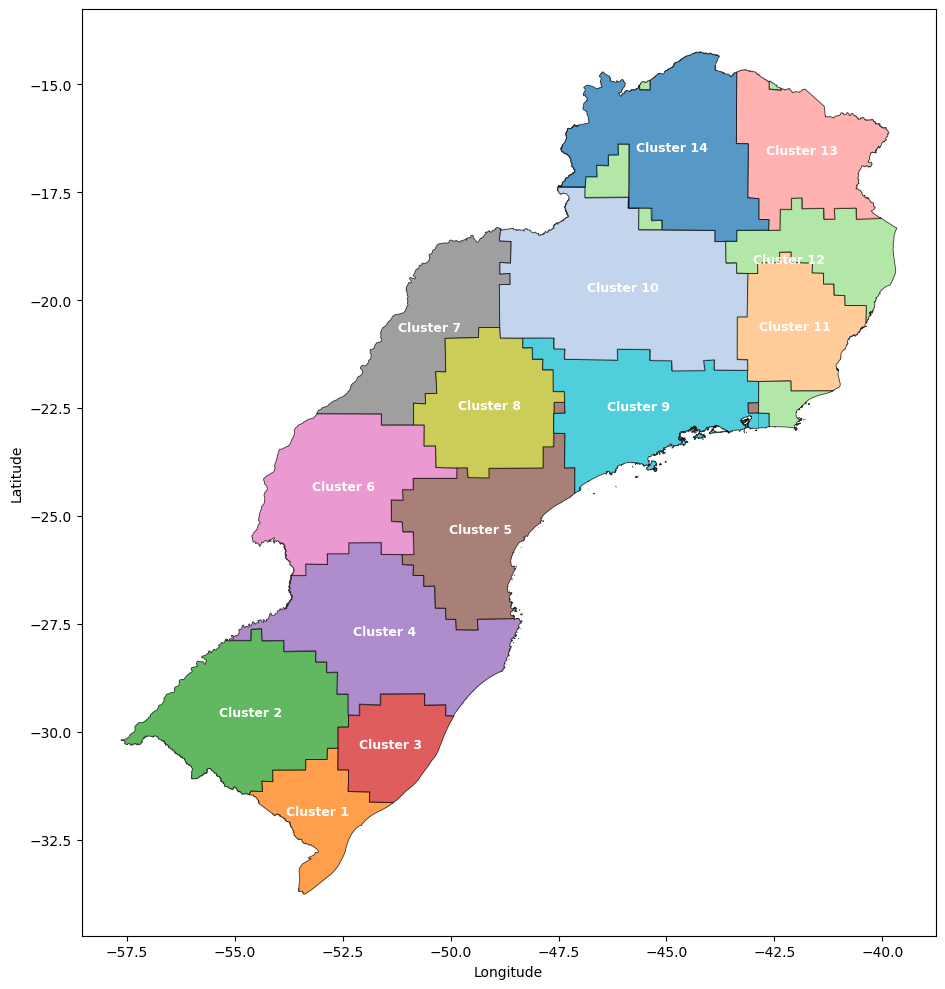

In [7]:
fig, ax = plt.subplots(figsize=(10, 10))

for i, row in gdf_clusters.iterrows():
    color = PALETTE[row["cluster_id"] % len(PALETTE)]
    gpd.GeoSeries([row.geometry], crs=gdf_clusters.crs).plot(
        ax=ax, color=color, edgecolor="black", linewidth=0.6, alpha=0.75,
    )
    centroid = row.geometry.centroid
    ax.annotate(
        row["cluster_name"], (centroid.x, centroid.y),
        ha="center", va="center", fontsize=9, fontweight="bold",
        color="white",
    )

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Isolar a máscara do cluster 3

In [4]:
mask_c3 = gdf_clusters[gdf_clusters["cluster_id"] == TARGET_CLUSTER].copy()
assert len(mask_c3) == 1, f"esperava 1 polígono para o cluster {TARGET_CLUSTER}, achei {len(mask_c3)}"

row_c3 = mask_c3.iloc[0]
bounds = row_c3.geometry.bounds
print(f"cluster_id     : {row_c3['cluster_id']}")
print(f"cluster_name   : {row_c3['cluster_name']}")
print(f"geometry type  : {row_c3.geometry.geom_type}")
print(f"área (km²)     : {row_c3['AREA_KM2']:.2f}")
print(f"bounds (lon/lat): {bounds}")

cluster_id     : 3
cluster_name   : Cluster 3
geometry type  : Polygon
área (km²)     : 248219.48
bounds (lon/lat): (-52.624137270963836, -31.632698228411993, -49.93490879703751, -29.117043129368618)


## Conferência visual — cluster 3 isolado

Contexto (demais clusters) em cinza claro, cluster 3 destacado.

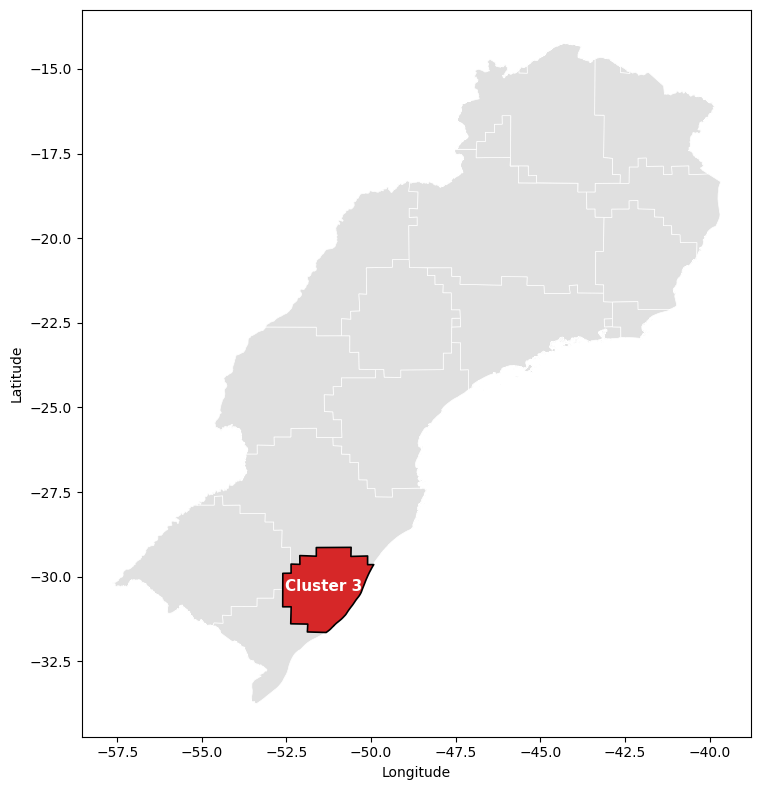

In [8]:
fig, ax = plt.subplots(figsize=(8, 8))

gdf_clusters.plot(ax=ax, color="#e0e0e0", edgecolor="white", linewidth=0.5)
mask_c3.plot(ax=ax, color=PALETTE[TARGET_CLUSTER % len(PALETTE)], edgecolor="black", linewidth=1.2)

centroid = row_c3.geometry.centroid
ax.annotate(
    row_c3["cluster_name"], (centroid.x, centroid.y),
    ha="center", va="center", fontsize=11, fontweight="bold", color="white",
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Exportar a máscara do cluster 3

In [6]:
geojson_path = OUT_DIR / f"cluster_{TARGET_CLUSTER}_mask.geojson"
shp_path = OUT_DIR / f"cluster_{TARGET_CLUSTER}_mask.shp"

mask_c3.to_file(geojson_path, driver="GeoJSON")
mask_c3.to_file(shp_path)

print(f"GeoJSON salvo em: {geojson_path.resolve()}")
print(f"Shapefile salvo em: {shp_path.resolve()}")

GeoJSON salvo em: /media/matteuscruz/Projects/Entrep/irc_vendaval/artifacts/cluster_masks/cluster_3_mask.geojson
Shapefile salvo em: /media/matteuscruz/Projects/Entrep/irc_vendaval/artifacts/cluster_masks/cluster_3_mask.shp


/tmp/ipykernel_38138/564558303.py:5: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  mask_c3.to_file(shp_path)
/media/matteuscruz/Projects/Entrep/irc_vendaval/.venv/lib/python3.11/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'cluster_name' to 'cluster_na'
  ogr_write(
